In [1]:
# import pandas as pd
import networkx as nx                         # for creating graphs
from node2vec import Node2Vec                 # for node2vec algorithm
from node2vec.edges import HadamardEmbedder    
import matplotlib.pyplot as plt               # for plotting the graphs
import random                                 # for random.choice() function
import pandas as pd

/Users/Joseph.Boltman/.pyenv/versions/general_work_env/lib/python3.8/site-packages/pandas/compat/__init__.py:117: UserWarning: Could not import the lzma module. Your installed Python is incomplete. Attempting to use lzma compression will result in a RuntimeError.
  warnings.warn(msg)


# Graphs in Python using *networkx* package

In [2]:
# initialise an empty graph object:
mygraph = nx.Graph()
mygraph

In [3]:
# list of people:
people = ['person A', 'person B', 'person C', 'person D', 'person E', 'person F', 'person G']
#people = ['person A', 'person B', 'person C', 'person D']

# list of restaurants:
restaurants = ['chinese', 'burgers', 'sushi', 'pizza', 'chicken', 'thai', 'coffee', 'alcohol', 'pancakes', 'african\ncuisine', 'korean', 'hotdogs', 'tea', 'vegan', 'french \nfood', 'ice-cream']
#restaurants = ['chinese', 'burgers', 'sushi', 'pizza', 'chicken']

# add all people to the graph:
for i in people:
    mygraph.add_node(i)
    
# add all restaurants to the graph:    
for i in restaurants:
    mygraph.add_node(i)
    
# add random people/restaurant connections to the graph:
for i in range(10):
    # add a random restaurant/person edge: 
    mygraph.add_edge(random.choice(people),
                     random.choice(restaurants),
                     weight=1      # give this edge weight 1
                    )
    

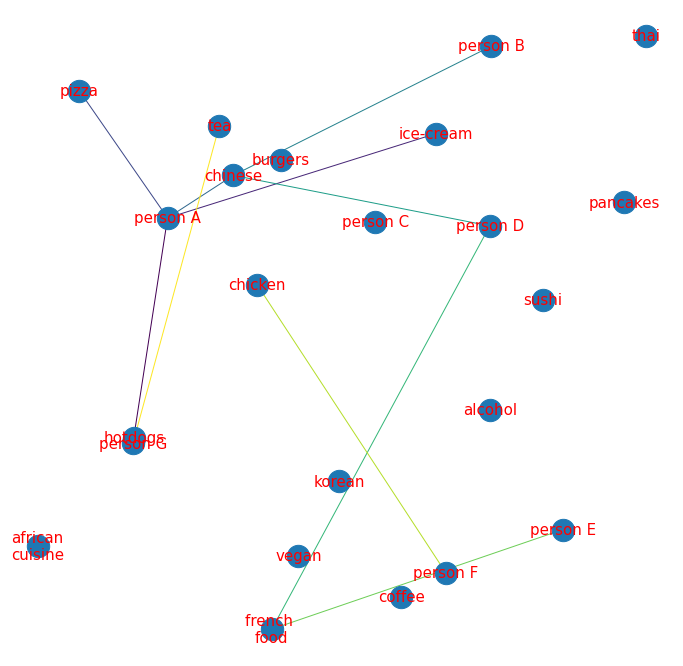

In [4]:
# draw our network/graph:
fig, ax = plt.subplots(figsize=(12, 12))

node_pos = nx.spring_layout(mygraph, iterations=1)  # positions for all nodes

# nodes
nx.draw_networkx_nodes(mygraph, node_pos, node_size=500)

# edges
nx.draw_networkx_edges( mygraph, 
                        node_pos,
                        edgelist = mygraph.edges,
                        width = 1,
                        edge_color = range(len(mygraph.edges))
                      )

# labels
nx.draw_networkx_labels(mygraph, node_pos, font_size=15, font_family='sans-serif', font_color='r')

plt.axis('off')
plt.show()

# Node2Vec

What the Node2Vec algorithm does is to take a graph, then to try to represent the information in that graph in a vector space.

This is convenient, because standard predictive models need data stored as a vector-space. 

Each node in the original graph is represented as a single vector in the vector space created by Node2Vec. 

For each node **u** in the graph, the Node2Vec algorithm defines a **neighbourhood** of nodes around **u** by starting out at node **u** and exploring the graph (i.e. travelling between nodes). How the graph is explored is random, where the nature of the random exploration is controlled by user-chosen parameters.

In [5]:
# Precompute probabilities and generate walks - **ON WINDOWS ONLY WORKS WITH workers=1**
# (for documentation refer to https://github.com/eliorc/node2vec)
node2vec = Node2Vec( graph = mygraph,
                     dimensions = 2,      # number of dimensions of vector space created by Node2Vec
                     walk_length = 3,    # number of nodes travelled to in each walk
                     num_walks = 10,      # number of walks performed per node
                     p = 1,             # 'Return' hyper parameter (default: 1)
                     q = 1,              # 'In Out' parameter (default: 1)
                     workers = 1       # number of workers to use in parallel execution
                   )

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:00<00:00, 125.48it/s]


In [6]:
# Embed nodes
model = node2vec.fit( window = 3, # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
                      min_count = 1,
                      batch_words = 4
                    )  

In [7]:
# get the embeddings for the people in the graph:
people_embeddings = {}
for i in people:
    people_embeddings[i] = model.wv[i]

people_embeddings

{'person A': array([-0.15352549,  0.18071742], dtype=float32),
 'person B': array([-0.01416608,  0.09579097], dtype=float32),
 'person C': array([ 0.24177921, -0.03524455], dtype=float32),
 'person D': array([-0.10408711, -0.08194884], dtype=float32),
 'person E': array([0.00943416, 0.09439383], dtype=float32),
 'person F': array([-0.01703384, -0.12535486], dtype=float32),
 'person G': array([ 0.01978231, -0.1536835 ], dtype=float32)}

In [8]:
# get the embeddings for the restaurants in the graph:
restaurant_embeddings = {}
for i in restaurants:
    restaurant_embeddings[i] = model.wv[i]

restaurant_embeddings

{'chinese': array([0.20849071, 0.0628915 ], dtype=float32),
 'burgers': array([-0.04519508,  0.09146757], dtype=float32),
 'sushi': array([0.03909405, 0.13468008], dtype=float32),
 'pizza': array([ 0.12511574, -0.21415147], dtype=float32),
 'chicken': array([0.08628924, 0.22495766], dtype=float32),
 'thai': array([0.14223829, 0.23810928], dtype=float32),
 'coffee': array([0.02481056, 0.12155808], dtype=float32),
 'alcohol': array([-0.09200921, -0.18742731], dtype=float32),
 'pancakes': array([-0.17417446, -0.14321956], dtype=float32),
 'african\ncuisine': array([0.10928748, 0.17189433], dtype=float32),
 'korean': array([0.11969182, 0.0124065 ], dtype=float32),
 'hotdogs': array([-0.23432344,  0.14195506], dtype=float32),
 'tea': array([0.22790511, 0.24094327], dtype=float32),
 'vegan': array([0.00480845, 0.04615328], dtype=float32),
 'french \nfood': array([ 0.1517248 , -0.21757017], dtype=float32),
 'ice-cream': array([-0.18421158, -0.21418768], dtype=float32)}

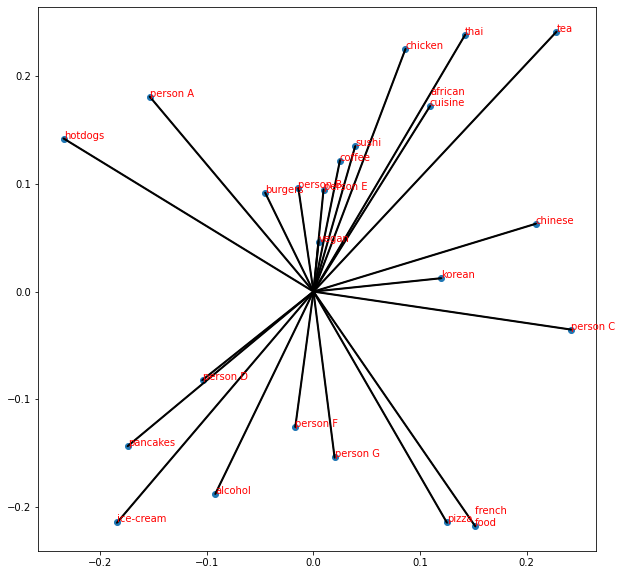

In [9]:
# plot the embeddings in the vector space created by Node2Vec:
plot_x = [i[0] for i in people_embeddings.values()] + [i[0] for i in restaurant_embeddings.values()]
plot_y = [i[1] for i in people_embeddings.values()] + [i[1] for i in restaurant_embeddings.values()]
point_labels = list(people_embeddings.keys()) + list(restaurant_embeddings.keys())

fig, ax = plt.subplots(figsize=(10, 10))     # make the plot nice and big

ax.scatter( x = plot_x, 
            y = plot_y
           )           # create the scatterplot

# label points:
for i, txt in enumerate(point_labels):
    ax.annotate(txt, (plot_x[i], plot_y[i]), color='red')

# draw arrows from origin to points:
for i in range(len(plot_x)):
    ax.arrow(0, 0, plot_x[i], plot_y[i], head_width=0.001, head_length=0.001, fc='k', ec='k')
    
plt.show()

In [10]:
# Embed edges using Hadamard method
edges_embs = HadamardEmbedder(keyed_vectors=model.wv)

In [11]:
# Get all edges in a separate KeyedVectors instance - use with caution could be huge for big networks
edges_kv = edges_embs.as_keyed_vectors()

Generating edge features: 100%|██████████| 276/276.0 [00:00<00:00, 122890.44it/s]


# Nice Resources

* [networkx officical documentation tutorial](https://networkx.github.io/documentation/stable/tutorial.html)

* [networkx official documentation introduction](https://networkx.github.io/documentation/stable/reference/introduction.html)

* [Original Node2Vec paper](https://cs.stanford.edu/~jure/pubs/node2vec-kdd16.pdf)

* [Node2Vec python library documentation](https://github.com/eliorc/node2vec)